# M4: LSTM

Ova sveska trenira i ocenjuje M4 LSTM nad sekvencama prethodno odigranih mečeva. LSTM je glavni model projekta.

Svaka rekurentna mreža ima svoju svesku, da bi se moglo raditi paralelno. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu petlju treniranja, ali je svaka podešena nezavisno. LSTM i GRU imaju kapije i više parametara, pa im ne odgovara isto podešavanje kao običnoj RNN. Poređenje M3, M4 i M5 zato pokazuje najbolju verziju svake, a ne uticaj tipa ćelije.

Potpuno izvršavanje traje oko 14 minuta i istrenira oko sto dvadeset modela.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.config import (BATCH_SIZE, MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE,
                        RAW_STAT_COLUMNS, RESULTS_FILE, SEEDS, SEQUENCE_FEATURE_COLUMNS)
from src import data, evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 - isti mečevi kao za M0-M3, kako bi poređenje bilo pošteno. Test skup se ovde ne učitava: dodiruje se tačno jednom, na kraju.

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape

((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe - ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)

(18092, 2624)

## Izbor hiperparametara

Hiperparametri se biraju pre treniranja, jer sve što sledi zavisi od njih. Pretraga ide u dva koraka.

Prvo gruba pretraga po celoj mreži vrednosti iz `config.py`, sa jednim semenom po kombinaciji. Zatim se prvih `N_FINALISTS` kandidata trenira ponovo, sa svih pet semena, i pobednik se bira po proseku.

Drugi korak postoji zato što jedno merenje po kombinaciji nije dovoljno da ih razdvoji. Mreža vrednosti i broj finalista stoje u `config.py`, isti za sve tri rekurentne mreže.

**Prvi korak - gruba pretraga.** Jedno seme po kombinaciji, poredak po `roc_auc` na validaciji.

In [4]:
rezultati_pretrage = train.search_hyperparameters(
    loader_train, loader_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
)

rezultati_pretrage.head(5).round(4)

,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,32,0.30,0.003,0.6566,0.6980,0.6174,0.2142
1,128,0.00,0.003,0.6547,0.6980,0.6172,0.2140
2,32,0.15,0.003,0.6566,0.6978,0.6187,0.2147
3,32,0.00,0.003,0.6543,0.6976,0.6178,0.2143
4,32,0.30,0.001,0.6532,0.6967,0.6183,0.2146


Drugi korak. Svaki finalista se trenira pet puta, pa se poredi prosek. Kolona `rasipanje` pokazuje koliko se ishod menja od pokretanja do pokretanja.

In [5]:
finalisti = train.refine_hyperparameters(
    rezultati_pretrage, dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
)

finalisti.round(4)

,hidden_size,dropout,learning_rate,tacnost,rasipanje,roc_auc,roc_auc_rasipanje
0,32,0.30,0.003,0.6566,0.0018,0.6969,0.0017
1,128,0.00,0.003,0.6566,0.0025,0.6968,0.0010
2,32,0.15,0.003,0.6564,0.0024,0.6965,0.0014
3,32,0.00,0.003,0.6565,0.0026,0.6963,0.0012
4,32,0.30,0.001,0.6555,0.0019,0.6952,0.0004


In [6]:
najbolji = finalisti.iloc[0]

print(f"hidden_size   {int(najbolji['hidden_size'])}")
print(f"dropout       {najbolji['dropout']}")
print(f"learning_rate {najbolji['learning_rate']}")
print(f"roc_auc       {najbolji['roc_auc']:.4f} +- {najbolji['roc_auc_rasipanje']:.4f}")
print(f"tacnost       {najbolji['tacnost']:.4f} +- {najbolji['rasipanje']:.4f}")

hidden_size   32
dropout       0.3
learning_rate 0.003
roc_auc       0.6969 +- 0.0017
tacnost       0.6566 +- 0.0018


Drugi korak je potvrdio pobednika grube pretrage, ali je pokazao i da izbor nije oštar.

Svih pet finalista staje u raspon od 0.0017 ROC-AUC, koliko iznosi i najveće pojedinačno rasipanje. Prva četiri su još bliža, unutar 0.0006. Nijedan se ne izdvaja od ostalih.

Najjasnije se to vidi na prva dva mesta: `hidden_size=32` i `hidden_size=128` daju istu tačnost do četvrte decimale. Enkoder četiri puta veći ne menja ništa.

Izabrana stopa učenja `0.003` je najveća u mreži. Šta leži izvan te granice proverava se na kraju sveske.

Kombinacije sa `dropout=0.00` daju praktično isti ROC-AUC kao izabrana `0.30`.

Razlog je u tome gde dropout deluje. `MatchPredictor` ga primenjuje pre spajanja sa kontekstom, samo na izlaz enkodera, pa kontekst i Elo kroz njega ne prolaze. Ablacija niže pokazuje da baš taj deo ulaza ne doprinosi merljivo.

## Kreiranje mreže

`cell="lstm"` daje M4 LSTM.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [7]:
train.set_seed(RANDOM_STATE)

model_lstm = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
)
model_lstm


MatchPredictor(
  (encoder): LSTM(8, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=88, out_features=1, bias=True)
)

## Treniranje mreže

Ista postavka se trenira pet puta, po jednom za svako seme iz `config.SEEDS`, jer su početne težine i redosled paketića slučajni.

Prijavljena metrika je prosek po semenima. Grafici i matrica konfuzije se crtaju za jedan model, pa za njih služi prolaz sa semenom `RANDOM_STATE`.

In [8]:
prolazi = train.train_over_seeds(
    dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
    learning_rate=float(najbolji["learning_rate"]),
)

# reprezentativni prolaz - onaj sa semenom iz config.py; sluzi za grafike,
# matricu konfuzije i kalibraciju, koje se crtaju za jedan model
model_lstm = next(p["model"] for p in prolazi if p["seed"] == RANDOM_STATE)
history = next(p["history"] for p in prolazi if p["seed"] == RANDOM_STATE)

pd.DataFrame([{
    "seed": p["seed"],
    "epoha": len(p["history"]["train_loss"]),
    "najbolja": int(np.argmin(p["history"]["valid_loss"])) + 1,
    **p["metrike"],
} for p in prolazi]).round(4)

,seed,epoha,najbolja,tacnost,roc_auc,log_loss,brier
0,7,9,4,0.6570,0.6973,0.6171,0.2141
1,17,12,7,0.6543,0.6976,0.6173,0.2141
2,27,7,2,0.6559,0.6941,0.6197,0.2152
3,37,11,6,0.6559,0.6991,0.6162,0.2137
4,47,8,3,0.6597,0.6964,0.6181,0.2144


## Krive učenja

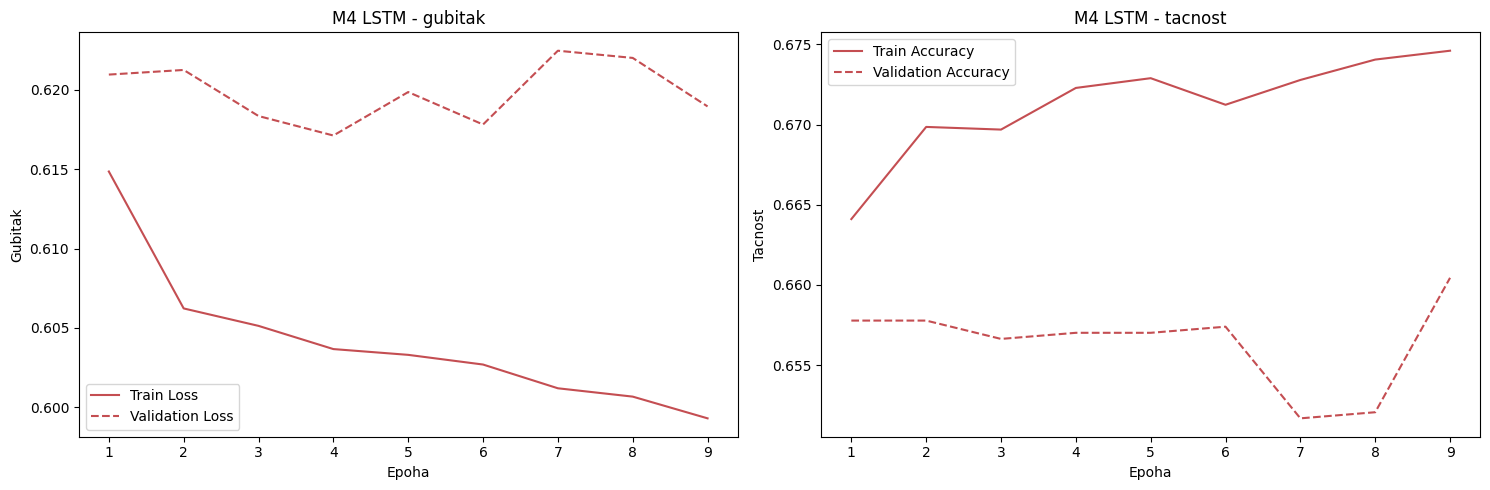

najbolja epoha: 4 od 9
validacioni gubitak: prva epoha 0.6210, najbolja 0.6171, poslednja 0.6190
razmak trening-validacija: 0.006 -> 0.020
validaciona tacnost: od 0.6517 do 0.6604


In [9]:
plotting.plot_learning_curves(history, "M4 LSTM")

najbolja = int(np.argmin(history["valid_loss"]))
print(f"najbolja epoha: {najbolja + 1} od {len(history['valid_loss'])}")
print(f"validacioni gubitak: prva epoha {history['valid_loss'][0]:.4f},"
      f" najbolja {history['valid_loss'][najbolja]:.4f},"
      f" poslednja {history['valid_loss'][-1]:.4f}")
print(f"razmak trening-validacija: {history['valid_loss'][0] - history['train_loss'][0]:.3f}"
      f" -> {history['valid_loss'][-1] - history['train_loss'][-1]:.3f}")
print(f"validaciona tacnost: od {min(history['valid_accuracy']):.4f}"
      f" do {max(history['valid_accuracy']):.4f}")

Levi grafik pokazuje gubitak. Trening opada kroz sve epohe, a validacija dostiže minimum u 4. i onda raste. Do 9. epohe se skoro vratila na početnu vrednost (0.6190 naspram 0.6210). Razmak između krivih raste sa 0.006 na 0.020, što je znak preprilagođavanja koje rano zaustavljanje hvata.

Desni grafik pokazuje tačnost. Validaciona kriva nema trend, već osciluje između 0.6517 i 0.6604. To je raspon od 0.87 procentnih poena kod jednog istog modela, samo kroz epohe.

Prikazan je prolaz sa semenom 7. Po tabeli iznad, najbolja epoha se među semenima kreće od 2 do 7.

## Evaluacija modela

Matrica konfuzije, metrike po klasi i kalibracija na validaciji; zbirne metrike idu u `reports/rezultati.csv`. Test skup se ovde ne dodiruje.

Klase nisu u ravnoteži, pa tačnost sažima dva vrlo različita ponašanja. Preciznost, odziv i F1 po klasi ih razdvajaju.

In [10]:
loader_train_eval = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=False)

for skup, loader in [("trening", loader_train_eval), ("validacija", loader_val)]:
    po_semenu = []

    for prolaz in prolazi:
        y_proba, y_true = train.predict_proba(prolaz["model"], loader)
        metrike = evaluate.compute_metrics(y_true, y_proba)
        evaluate.append_seed_results("M4 LSTM", skup, prolaz["seed"], metrike)
        po_semenu.append(metrike)

    prosek = {kljuc: float(np.mean([m[kljuc] for m in po_semenu])) for kljuc in po_semenu[0]}
    evaluate.append_results("M4 LSTM", skup, prosek)

# test redovi se ovde ne prikazuju: ova sveska ih ne racuna i ne sme da
# ih otkrije, jer se test otvara tek u svesci 05-01
pd.read_csv(RESULTS_FILE).query("skup != 'test'").reset_index(drop=True)

,model,skup,tacnost,roc_auc,log_loss,brier
0,M3 RNN,trening,0.673281,0.714217,0.602742,0.208053
1,M3 RNN,validacija,0.658537,0.697448,0.617042,0.214006
2,M5 GRU,trening,0.673889,0.715839,0.601378,0.207469
3,M5 GRU,validacija,0.655107,0.698265,0.617979,0.214296
4,M0 domacin,trening,0.599547,0.500000,0.673195,0.240090
5,M0 domacin,validacija,0.588796,0.500000,0.677534,0.242231
6,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
7,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
8,M2 XGBoost,trening,0.683396,0.731799,0.590812,0.202857
9,M2 XGBoost,validacija,0.657012,0.699032,0.616667,0.213756


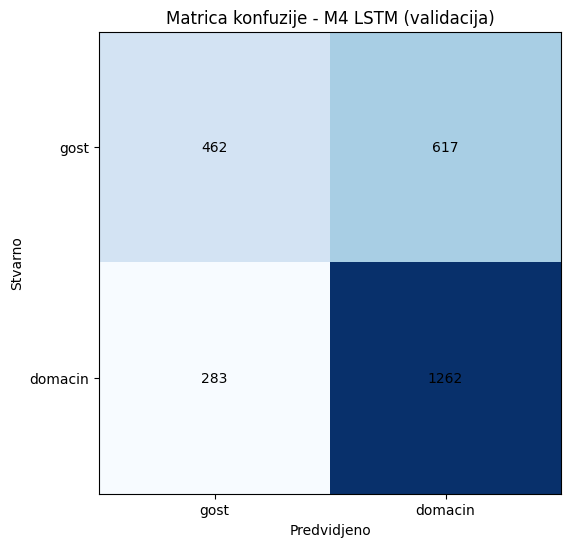

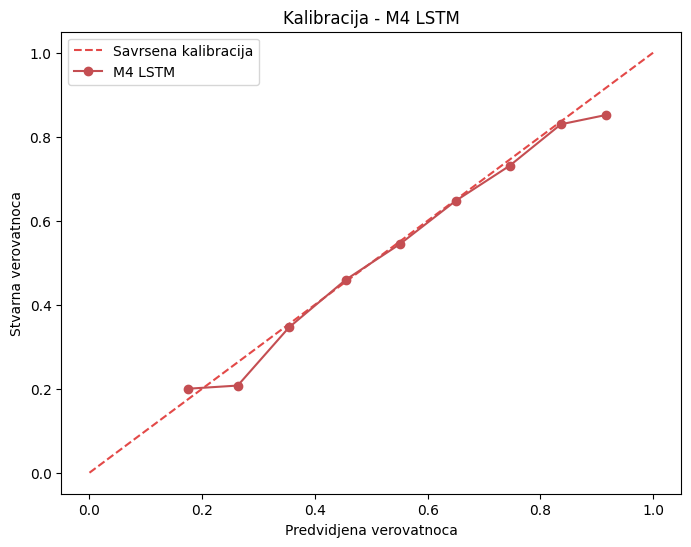

In [11]:
y_proba_val, y_true_val = train.predict_proba(model_lstm, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M4 LSTM (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M4 LSTM")

In [12]:
print(evaluate.compute_class_report(y_true_val, y_pred_val))

              precision    recall  f1-score   support

        gost      0.620     0.428     0.507      1079
     domacin      0.672     0.817     0.737      1545

    accuracy                          0.657      2624
   macro avg      0.646     0.623     0.622      2624
weighted avg      0.650     0.657     0.642      2624



Model mnogo bolje prepoznaje domaćine nego goste: odziv je 0.817 naspram 0.428.

Preciznost za goste je 0.620, dakle kad model kaže „gost", uglavnom je u pravu. Problem je što to retko kaže - domaćina prijavljuje na oko 72% mečeva, iako domaćin pobeđuje u 58.9%. Prag 0.5 nad neuravnoteženim klasama vuče predviđanja ka većoj klasi. Zato je makro F1 (0.622) niži od tačnosti (0.657).

ROC-AUC, log-gubitak i Brier ostaju glavne metrike. Tačnost, preciznost, odziv i F1 traže prag, a prag briše razliku između meča ocenjenog na 0.51 i onog na 0.95. Zadatak traži verovatnoću, ne odluku.

Kalibracija pokazuje da model to radi solidno: kad kaže 0.65, tačan je u oko 65% slučajeva.

## Ablacija: šta zapravo doprinosi rezultatu

M4 dobija dve vrste ulaza: sekvence prethodnih mečeva i kontekst tekućeg meča. Kontekst nosi skoro isto što i M1 - Elo, međusobne duele i stanje na tabeli.

Pošto M4 završava blizu M1, postavlja se pitanje koji deo mreže zapravo radi posao. Meri se tako što se svaki ulaz redom zameni nulama, uz nepromenjenu arhitekturu. Uz to se proverava i da li bi izlazna glava trebalo da ima skriveni sloj.

Sve varijante koriste iste hiperparametre kao M4, pa je red „pun model" isti model kao gore.

In [13]:
class GlavaSaSkrivenimSlojem(models.MatchPredictor):
    """Ista mreza, ali izlaz ide kroz skriveni sloj umesto pravo u jedan Linear."""

    def __init__(self, n_features, n_context, cell="lstm", hidden_size=None, dropout=None):
        # bez podrazumevanih vrednosti - one bi se razisle sa izborom pretrage
        super().__init__(n_features, n_context, cell, hidden_size, dropout)
        self.output = nn.Sequential(
            nn.Linear(2 * hidden_size + n_context, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1),
        )


In [14]:
def ucitavaci(seme, bez_sekvenci=False, bez_konteksta=False, transform=None):
    """Vraca par ucitavaca u kojima je izabrani ulaz zamenjen nulama ili preobrazen.

    transform dobija i niz pozicija, da bi preobrazaj mogao da zavisi od toga
    kojoj sezoni mec pripada.
    """
    def skup(i):
        h, a, x, y = home_sequences[i], away_sequences[i], context[i], labels[i]
        if bez_sekvenci:
            h, a = np.zeros_like(h), np.zeros_like(a)
        if bez_konteksta:
            x = np.zeros_like(x)
        if transform is not None:
            h, a = transform(h, i), transform(a, i)
        return sequences.MatchSequenceDataset(h, a, x, y)

    generator = torch.Generator().manual_seed(seme)
    return (DataLoader(skup(train_idx), batch_size=BATCH_SIZE, shuffle=True, generator=generator),
            DataLoader(skup(validation_idx), batch_size=BATCH_SIZE, shuffle=False))


In [15]:
def oceni(klasa=models.MatchPredictor, learning_rate=None, **kw):
    """Trenira varijantu sa tri semena; vraca prosek, rasipanje i najvecu normu."""
    if learning_rate is None:
        learning_rate = float(najbolji["learning_rate"])

    tacnosti, auc, norme = [], [], []

    for seme in SEEDS:
        train.set_seed(seme)
        loader_t, loader_v = ucitavaci(seme, **kw)
        model = klasa(
            home_train.shape[-1], context_train.shape[-1], cell="lstm",
            hidden_size=int(najbolji["hidden_size"]), dropout=float(najbolji["dropout"]),
        )
        istorija = train.train_model(
            model, loader_t, loader_v, epochs=100, patience=5, learning_rate=learning_rate
        )
        proba, y = train.predict_proba(model, loader_v)
        metrike = evaluate.compute_metrics(y, proba)
        tacnosti.append(metrike["tacnost"])
        auc.append(metrike["roc_auc"])
        norme.append(max(istorija["grad_norm"]))

    return {"tacnost": np.mean(tacnosti), "rasipanje": np.std(tacnosti),
            "roc_auc": np.mean(auc), "max_norma": max(norme)}


In [16]:
varijante = {
    "pun model": dict(),
    "glava sa skrivenim slojem": dict(klasa=GlavaSaSkrivenimSlojem),
    "samo kontekst (sekvence = 0)": dict(bez_sekvenci=True),
    "samo sekvence (kontekst = 0)": dict(bez_konteksta=True),
}

pd.DataFrame(
    [oceni(**kw) for kw in varijante.values()], index=list(varijante)
)[["tacnost", "rasipanje", "roc_auc"]].round(4)


,tacnost,rasipanje,roc_auc
pun model,0.6566,0.0018,0.6969
glava sa skrivenim slojem,0.6535,0.0017,0.6954
samo kontekst (sekvence = 0),0.6572,0.0019,0.6967
samo sekvence (kontekst = 0),0.6314,0.0031,0.6641


Sve razlike u tabeli osim jedne su reda veličine šuma. Tri varijante staju između 0.6535 i 0.6572, uz rasipanje po semenima od 0.0017 do 0.0019.

Kontekst nosi skoro sve. Bez njega tačnost pada na 0.6314, što je 2.5 procentna poena ispod punog modela i jedina razlika veća od šuma.

Sekvence ne dodaju ništa merljivo. Bez njih model daje 0.6572, sa njima 0.6566. Razlika od 0.06 procentna poena je tri puta manja od rasipanja, pa se ne može reći ni da pomažu ni da odmažu. Nalaz je da se razlika ne vidi.

Sekvence ipak nisu prazne. Same, bez konteksta, daju 0.6314 naspram 0.5888 koliko daje „uvek domaćin". To jeste signal o formi tima, ali ga Elo i tabela očigledno već sadrže.

Skriveni sloj ne pomaže. Daje 0.6535 naspram 0.6566 za jedan `Linear`, dakle nema traga od dobitka.

Kolona `rasipanje` je standardna devijacija po pet semena. Ona meri koliko se ishod menja od pokretanja do pokretanja, a ne koliko bi se menjao na drugim mečevima, pa nije interval poverenja.

### Na koliko mečeva se modeli uopšte razlikuju

Razlika od 0.06 procentna poena je oko dva meča od 2624, u proseku po pet semena. Vredi videti na koliko mečeva dva modela uopšte daju različit odgovor. Ovo je prebrojavanje, ne test.

In [17]:
def predvidjanja(**kw):
    """Trenira jednu varijantu i vraca (predvidjeno, stvarno) na validaciji."""
    train.set_seed(RANDOM_STATE)
    loader_t, loader_v = ucitavaci(RANDOM_STATE, **kw)
    model = models.MatchPredictor(
        home_train.shape[-1], context_train.shape[-1], cell="lstm",
        hidden_size=int(najbolji["hidden_size"]), dropout=float(najbolji["dropout"]),
    )
    train.train_model(
        model, loader_t, loader_v,
        epochs=100, patience=5, learning_rate=float(najbolji["learning_rate"]),
    )
    proba, y = train.predict_proba(model, loader_v)
    return (proba >= 0.5).astype(int), y.astype(int)

In [18]:
pred_pun, y_val_bin = predvidjanja()
pred_bez, _ = predvidjanja(bez_sekvenci=True)

neslaganja = pred_pun != pred_bez
pun_u_pravu = int((neslaganja & (pred_pun == y_val_bin)).sum())
bez_u_pravu = int((neslaganja & (pred_bez == y_val_bin)).sum())

print(f"od {len(y_val_bin)} meceva modeli se razlikuju u {int(neslaganja.sum())}:")
print(f"  pun model u pravu {pun_u_pravu}, bez sekvenci u pravu {bez_u_pravu}")

od 2624 meceva modeli se razlikuju u 85:
  pun model u pravu 38, bez sekvenci u pravu 47


Modeli se slažu na 2539 od 2624 meča, dakle 96.8%. Na 85 mečeva gde se razilaze, varijanta bez sekvenci je u pravu na 47, a pun model na 38.

### Provera: covariate shift u sekvencama

Skaler je istreniran na sezonama do 2016/17, a prosečni poeni su u međuvremenu porasli sa 94.9 na 114.9 (sveska 01). Sekvence iz kasnijih sezona zato ulaze u mrežu sistematski pomerene. Elo i procenti pobeda tome ne podležu jer su po konstrukciji nula-sume.

To je moguće nezavisno objašnjenje zašto rekurentna grana zaostaje.

In [19]:
pomak = pd.DataFrame({
    ime: [home_sequences[i][:, :, j].mean() for i in (train_idx, validation_idx)]
    for j, ime in enumerate(SEQUENCE_FEATURE_COLUMNS)
}, index=["trening", "validacija"]).T
pomak["pomak"] = pomak["validacija"] - pomak["trening"]
pomak.round(3)

,trening,validacija,pomak
PTS,-0.005,0.745,0.750
FG_PCT,0.001,0.115,0.114
FT_PCT,-0.001,0.115,0.116
FG3_PCT,0.001,0.047,0.046
AST,-0.003,0.452,0.455
REB,-0.007,0.330,0.338
WON,-0.003,-0.002,0.001
IS_HOME,-0.028,-0.032,-0.004


Pomak je stvaran i velik. Vrednosti su u skaliranom prostoru, pa se čitaju kao broj standardnih devijacija trening skupa: `PTS` se pomera za 0.750, `AST` za 0.455, `REB` za 0.338.

`WON` i `IS_HOME` se ne pomeraju, jer su po prirodi nula-sume - u svakom meču neko pobedi i neko je domaćin.

Ako je pomak uzrok, uklanjanje nivoa iz sekvence bi trebalo da popravi rezultat. Postoje dva načina, i razlika je bitna.

Centriranje po sekvenci oduzima svakoj sekvenci njen sopstveni prosek. Time nestaje pomak, ali i razlika između jakog i slabog tima, koja je signal a ne šum. Kako su ta dva efekta suprotnog znaka, nulti ishod ne dokazuje ništa.

Z-skor po sezoni oduzima prosek lige u toj sezoni i deli devijacijom lige. Pomak nestaje, a razlika među timovima ostaje, pa je to test koji te dve stvari razdvaja.

Z-skor koristi statistiku cele sezone odjednom, pa nije postupak za predviđanje unapred. Ovde služi kao dijagnostika.

In [20]:
# sezona svakog meca - treba z-skoru, jer se normalizuje u odnosu na ligu te sezone
df_games = data.clean_games(data.load_games())
sezone_svih = df_games.loc[splits["indices"], "SEASON"].to_numpy()

pd.DataFrame(
    [[int(sezone_svih[p].min()), int(sezone_svih[p].max()), len(np.unique(sezone_svih[p]))]
     for p in (train_idx, validation_idx)],
    columns=["prva sezona", "poslednja sezona", "broj sezona"],
    index=["trening", "validacija"],
)


,prva sezona,poslednja sezona,broj sezona
trening,2003,2016,14
validacija,2017,2018,2


In [21]:
# kolone koje driftuju se traze po imenu, ne po polozaju - redosled u
# SEQUENCE_FEATURE_COLUMNS sme da se promeni bez tihe greske ovde
DRIFTUJUCE = [SEQUENCE_FEATURE_COLUMNS.index(ime) for ime in RAW_STAT_COLUMNS]


def centriraj(s, pozicije=None):
    """Oduzima sopstveni prosek sekvence po koloni; uklanja i nivo tima."""
    s = s.copy()
    s[:, :, DRIFTUJUCE] -= s[:, :, DRIFTUJUCE].mean(axis=1, keepdims=True)
    return s


def z_skor_po_sezoni(s, pozicije):
    """Standardizuje u odnosu na ligu u toj sezoni; cuva razliku medju timovima."""
    s = s.copy()
    sezone = sezone_svih[pozicije]

    for sezona in np.unique(sezone):
        u_sezoni = sezone == sezona
        blok = s[u_sezoni]
        deo = blok[:, :, DRIFTUJUCE]
        blok[:, :, DRIFTUJUCE] = (deo - deo.mean(axis=(0, 1))) / deo.std(axis=(0, 1))
        s[u_sezoni] = blok

    return s


Pre merenja tačnosti treba proveriti da transformacija stvarno uklanja pomak. Ako pomak ostane, nulti rezultat ne govori ništa o hipotezi, već samo da transformacija nije uspela.

In [22]:
def pomak_po_kolonama(transform=None):
    """Razlika prosecne vrednosti izmedju validacije i treninga, po kolonama."""
    h_trening, h_validacija = home_sequences[train_idx], home_sequences[validation_idx]
    if transform is not None:
        h_trening = transform(h_trening, train_idx)
        h_validacija = transform(h_validacija, validation_idx)
    return [h_validacija[:, :, j].mean() - h_trening[:, :, j].mean()
            for j in range(len(SEQUENCE_FEATURE_COLUMNS))]


pd.DataFrame({
    "sirovo": pomak_po_kolonama(),
    "centrirano": pomak_po_kolonama(centriraj),
    "z-skor po sezoni": pomak_po_kolonama(z_skor_po_sezoni),
}, index=SEQUENCE_FEATURE_COLUMNS).round(3)

,sirovo,centrirano,z-skor po sezoni
PTS,0.750,-0.000,-0.000
FG_PCT,0.114,-0.000,0.000
FT_PCT,0.116,-0.000,0.000
FG3_PCT,0.046,-0.000,-0.000
AST,0.455,-0.000,0.000
REB,0.338,0.000,0.000
WON,0.001,0.001,0.001
IS_HOME,-0.004,-0.004,-0.004


Obe transformacije rade ono što tvrde: pomak u kolonama koje driftuju pada sa 0.750 na nulu. `WON` i `IS_HOME` ostaju nepromenjeni, pa tabela usput potvrđuje i da se dira samo ono što treba.

In [23]:
pd.DataFrame(
    [oceni(**kw) for kw in (dict(), dict(transform=centriraj), dict(transform=z_skor_po_sezoni))],
    index=["sirove sekvence", "centrirane po sekvenci", "z-skor po sezoni"],
)[["tacnost", "rasipanje", "roc_auc"]].round(4)


,tacnost,rasipanje,roc_auc
sirove sekvence,0.6566,0.0018,0.6969
centrirane po sekvenci,0.6564,0.0013,0.6956
z-skor po sezoni,0.6558,0.0011,0.6965


Hipoteza je odbačena. Z-skor po sezoni daje 0.6558 naspram 0.6566 za sirove sekvence, razlika od 0.08 procentna poena, unutar rasipanja. ROC-AUC je praktično isti.

Pomak dakle postoji, izmeren je i uklonjen, a rezultat se nije promenio. Nije uzrok zaostajanja rekurentne grane.

Uklonjen je pomak u nivou sirovih statistika. Ako se kroz sezone menja i sama dinamika forme, to bi ostalo nedirnuto.

### Provera ivice mreže

Izabrana stopa učenja `0.003` je najveća u mreži iz `config.py`. Pošto je pobednik pao na samu granicu, vredi proveriti šta leži izvan nje.

In [24]:
IVICA = (0.003, 0.006, 0.01, 0.02, 0.05)

pd.DataFrame(
    [oceni(learning_rate=lr) for lr in IVICA], index=[f"lr = {lr}" for lr in IVICA]
).round(4)

,tacnost,rasipanje,roc_auc,max_norma
lr = 0.003,0.6566,0.0018,0.6969,1.2231
lr = 0.006,0.6581,0.0007,0.6971,1.2850
lr = 0.01,0.6563,0.0014,0.6962,1.3854
lr = 0.02,0.6530,0.0033,0.6924,1.5166
lr = 0.05,0.6568,0.0026,0.6910,2.0462


Optimum je nešto izvan mreže, ali plitko. Vrednost `0.006` daje 0.6581 naspram 0.6566, dobitak od 0.15 procentna poena, što je manje od rasipanja na izabranoj vrednosti. Iznad `0.01` se kvari: ROC-AUC pada, a rasipanje raste.

Norma gradijenta prelazi 1.0 na svim ispitanim vrednostima, i na izabranoj `0.003`, gde preko pet semena dostiže 1.223. Nema znakova nestabilnosti, ni `nan` vrednosti ni skokova gubitka, pa odsecanje nije uvedeno. 

## Čuvanje modela

Čuva se stanje sa najmanjim validacionim gubitkom, jer `train_model` vraća model sa učitanim najboljim težinama.

Snima se svih pet prolaza, ne samo reprezentativni, jer je prijavljena metrika prosek po semenima.

In [25]:
for prolaz in prolazi:
    train.save_model(prolaz["model"], f"lstm_seed{prolaz['seed']}.pt")

sorted(p.name for p in MODELS_PATH.glob("lstm_seed*.pt"))

['lstm_seed17.pt',
 'lstm_seed27.pt',
 'lstm_seed37.pt',
 'lstm_seed47.pt',
 'lstm_seed7.pt']

## Zaključak

M4 LSTM daje 65.7% tačnosti na validaciji (0.6566 ± 0.0018), uz ROC-AUC 0.697, log-gubitak 0.618 i Brier 0.214. Pretraga je izabrala `hidden_size=32`, `dropout=0.3` i `learning_rate=0.003`.

Prijavljena vrednost je prosek po pet semena. Pojedinačni prolazi idu od 0.6543 do 0.6597, a za grafike služi prolaz sa semenom `RANDOM_STATE`, koji je usput najbliži proseku.

Glavni nalaz sveske je da sekvence prethodnih mečeva ne donose merljivo poboljšanje preko onoga što Elo i tabela već nose. Razlika između punog modela i modela bez sekvenci je 0.06 procentna poena, tri puta manja od rasipanja. Modeli se slažu na 96.8% mečeva. Sekvence same nose signal, 63.1% naspram 58.9%, ali je taj signal redundantan.

Kovarijantni pomak je proveren kao nezavisno objašnjenje i odbačen.

Model je asimetričan: odziv je 0.817 za domaćine i 0.428 za goste. Pobedu domaćina najavljuje na oko 72% mečeva, iako domaćin pobeđuje u 58.9%.

Izbor hiperparametara nije oštar. U gruboj pretrazi prva dva mesta imaju isti ROC-AUC do četvrte decimale, a kad se finalisti izmere sa pet semena, prva četiri i dalje staju u 0.0006. Mreže sa 32 i sa 128 jedinica daju istu tačnost, pa ni veličina enkodera ne razdvaja kandidate.

Mreža ima 5 465 parametara nad 18 092 primera, od čega 5 376 otpada na enkoder a 89 na izlazni sloj. Razmak između treninga i validacije ostaje mali, 67.3% naspram 65.7%.